# Week 2 lecture: parameters, loss, and the derivative

A model is a rule with blanks in it. Fitting a model means filling in the blanks, so that we can make a rule that describes the data we are interested in *modeling*. The blanks are called *parameters*, and the rule is called a *loss function*. The loss function measures how well the model describes the data, and the parameters are the numbers that we can change to make the loss smaller.

This notebook covers what the blanks are, how to measure whether one filling-in beats another, and how a computer finds a better one without being told what better looks like.

Nothing here is graded. Run the cells, change numbers, break things. Passages marked **Aside** go past what class will cover but are useful context.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins").dropna()
 
# Mass in kilograms rather than grams, so the numbers stay readable.
flipper = torch.tensor(penguins["flipper_length_mm"].to_numpy(float))
mass = torch.tensor(penguins["body_mass_g"].to_numpy(float) / 1000)

print("penguins measured:", flipper.shape[0])
print("flipper length: %.0f to %.0f mm" % (flipper.min(), flipper.max()))
print("body mass:      %.2f to %.2f kg" % (mass.min(), mass.max()))

penguins measured: 333
flipper length: 172 to 231 mm
body mass:      2.70 to 6.30 kg


---

## A line and the two numbers in it

$$y = mx + b$$

$x$ goes in, $y$ comes out, $m$ is the slope, $b$ is the intercept.

The slope says how much the output rises when the input rises by one. It is a rate, the same kind of thing as miles per hour or milligrams per millilitre, and it comes from any two points on the line as rise over run:

$$m = \frac{y_2 - y_1}{x_2 - x_1}$$

Dividing an output by an input means a slope carries units: (units of $y$) per (unit of $x$). The units are how you read the number out loud, and reading it out loud is how you tell whether it is plausible.

### Two penguins

This dataset records 333 penguins. Take two:

| | species | flipper length | body mass |
|---|---|---|---|
| Bird A | Adelie | 192 mm | 3.725 kg |
| Bird B | Gentoo | 212 mm | 4.725 kg |

From A to B the mass rises by $4.725 - 3.725 = 1.000$ kg while the flipper lengthens by $212 - 192 = 20$ mm:

$$m = \frac{1.000 \text{ kg}}{20 \text{ mm}} = 0.0500 \text{ kg/mm}$$

Out loud: every extra millimetre of flipper goes with 50 more grams of penguin.

The slope fixes the tilt but not the height. Rearranging $y = mx + b$ gives $b = y - mx$, and using Bird A:

$$b = 3.725 - (0.0500)(192) = 3.725 - 9.600 = -5.875 \text{ kg}$$

In [ ]:
xa, ya = 192.0, 3.725   # Adelie
xb, yb = 212.0, 4.725   # Gentoo

#if y=mx+b, then m=(yb-ya)/(xb-xa) and b=ya-m*xa
m = (yb - ya) / (xb - xa)
b = ya - m * xa

print("rise      = %.3f kg" % (yb - ya))
print("run       = %.0f mm" % (xb - xa))
print("slope     = %.4f kg/mm" % m)
print("intercept = %.4f kg" % b)

rise      = 1.000 kg
run       = 20 mm
slope     = 0.0500 kg/mm
intercept = -5.8750 kg


### Why the intercept is negative

Take a 200 mm flipper. The slope alone gives $0.05 \times 200 = 10$ kg, about twice the heaviest penguin here. The tilt is right and the line is in the wrong place. Adding $-5.87$ brings it to $4.13$ kg, an ordinary penguin.

In [3]:
for f in (190.0, 200.0, 210.0):
    print("flipper %.0f mm:  slope alone %5.2f kg,  after the intercept %5.2f kg"
          % (f, 0.05 * f, 0.05 * f - 5.87))

flipper 190 mm:  slope alone  9.50 kg,  after the intercept  3.63 kg
flipper 200 mm:  slope alone 10.00 kg,  after the intercept  4.13 kg
flipper 210 mm:  slope alone 10.50 kg,  after the intercept  4.63 kg


The intercept sets height. Read literally it is the mass predicted for a 0 mm flipper, which is not a penguin and would not have negative mass if it were. But $x = 0$ sits far outside the range the data covers, 172 mm to 231 mm, and a line fitted inside that range promises nothing outside it. A parameter can be necessary and still mean nothing on its own.

### Two points is not a fit

That line used 2 penguins and ignored 331.

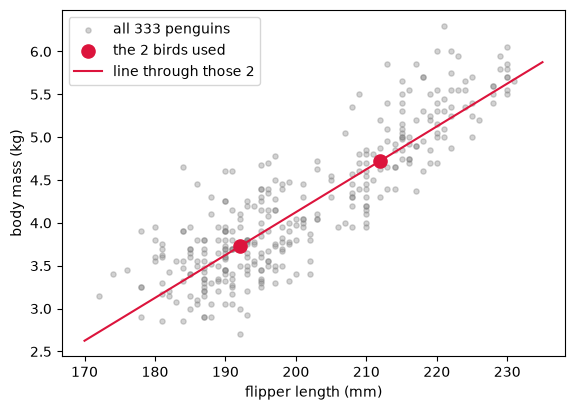

In [4]:
grid = torch.linspace(170, 235, 100)

plt.figure(figsize=(6.5, 4.5))
plt.scatter(flipper, mass, s=14, alpha=0.35, color="gray", label="all 333 penguins")
plt.scatter([xa, xb], [ya, yb], s=90, color="crimson", zorder=5, label="the 2 birds used")
plt.plot(grid, m * grid + b, color="crimson", label="line through those 2")
plt.xlabel("flipper length (mm)")
plt.ylabel("body mass (kg)")
plt.legend()
plt.show()

It came out well, which is luck. Other pairs give other lines:

In [5]:
for (x1, y1), (x2, y2) in [((192.0, 3.725), (212.0, 4.725)),
                           ((190.0, 3.650), (210.0, 4.000)),
                           ((195.0, 3.850), (215.0, 5.400))]:
    slope = (y2 - y1) / (x2 - x1)
    icept = y1 - slope * x1
    print("through (%.0f mm, %.3f kg) and (%.0f mm, %.3f kg):  m = %+.4f  b = %+.3f"
          % (x1, y1, x2, y2, slope, icept))

through (192 mm, 3.725 kg) and (212 mm, 4.725 kg):  m = +0.0500  b = -5.875
through (190 mm, 3.650 kg) and (210 mm, 4.000 kg):  m = +0.0175  b = +0.325
through (195 mm, 3.850 kg) and (215 mm, 5.400 kg):  m = +0.0775  b = -11.263


Three real pairs, three answers, no reason yet to prefer any. Two points can only ever agree with two points.

---

## Weights, biases, parameters

Same line, working notation:

$$y = wx + b$$

The rename is forced by what happens with more than one input. Four measurements means four slopes, each contributing at its own rate, and the contributions add:

$$y = w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + b$$

Four slopes, still one intercept. The two roles multiply differently so they need names that scale differently. This is not a new kind of mathematics, just the same line with more terms.

A **feature** is an input measurement, supplied by the data. Flipper length is a feature.

A **weight** multiplies a feature. It sets the rate at which that feature contributes, and carries units of (output units) per (unit of that feature). Changing it tilts the response to that one feature.

A **bias** is added to the output and multiplies nothing. It shifts every prediction equally. There is one bias no matter how many features.

A **parameter** is any number the model chooses. The weights and the bias are the parameters, and fitting means choosing them.

Features and weights sit side by side in the equation, multiplied together, looking symmetrical. They are not:

| | where it comes from | can fitting change it? |
|---|---|---|
| feature $x$ | measured from the world | no |
| target $y$ | measured from the world | no |
| weight $w$ | chosen by the model | yes |
| bias $b$ | chosen by the model | yes |

When a later week says a model has ten million parameters, that is ten million numbers in the bottom half.

### Reading three equations

$y = 3x + 7$. One feature, one weight of 3, bias 7, **2 parameters**. Raise $x$ by 1 and $y$ rises by 3.

$\text{mass} = 0.05 \times \text{flipper} - 5.87$. One feature, weight $0.05$ kg/mm, bias $-5.87$ kg, **2 parameters**.

$y = 2x_1 - 4x_2 + 0.5x_3 + 1$. Three features, weights $2$, $-4$, $0.5$, bias 1, **4 parameters**. The negative weight means raising that feature lowers the output. In a biological model that is often the interesting one, since it names something inhibitory.

A model with $n$ features has $n + 1$ parameters.

### What each one does

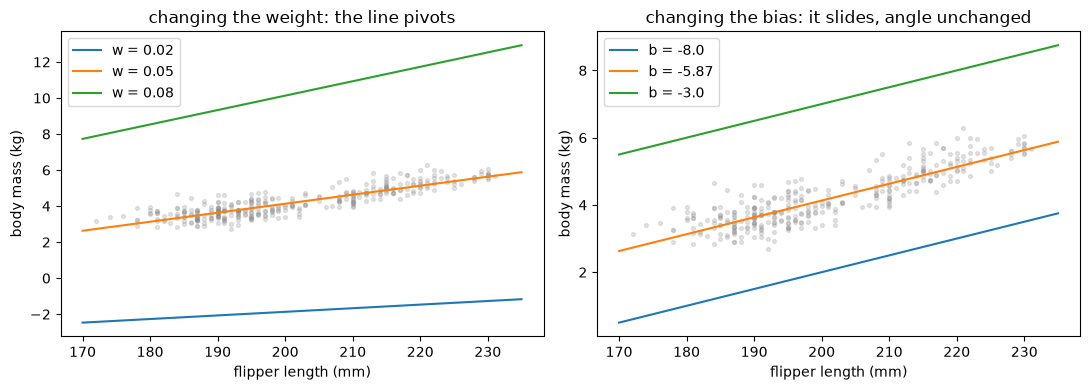

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].scatter(flipper, mass, s=8, alpha=0.2, color="gray")
for w_try in [0.02, 0.05, 0.08]:
    ax[0].plot(grid, w_try * grid - 5.87, label=f"w = {w_try}")
ax[0].set_title("changing the weight: the line pivots")

ax[1].scatter(flipper, mass, s=8, alpha=0.2, color="gray")
for b_try in [-8.0, -5.87, -3.0]:
    ax[1].plot(grid, 0.05 * grid + b_try, label=f"b = {b_try}")
ax[1].set_title("changing the bias: it slides, angle unchanged")

for a in ax:
    a.set_xlabel("flipper length (mm)")
    a.set_ylabel("body mass (kg)")
    a.legend()
plt.tight_layout()
plt.show()

Two knobs, two jobs. Fitting is the search for the setting of both that puts the line through the cloud.

A weight is a rate, so it reads as a sentence once you know the units:

| field | feature $x$ | target $y$ | what $w$ says |
|---|---|---|---|
| ecology | habitat area (ha) | species count | species gained per hectare |
| microbiology | time (h) | optical density | OD gained per hour |
| enzyme kinetics | substrate conc. (mM) | reaction rate | rate gained per mM |
| physiology | workload (W) | heart rate (bpm) | beats per minute per watt |

---

## Predictions and errors

A **prediction** is what the model returns, written $\hat{y}$ and said "y hat" to keep it apart from the true $y$. For a line, $\hat{y} = wx + b$.

An **error** is the prediction minus the truth, $\hat{y} - y$. It is signed: positive means the model guessed high, negative means low. On a plot it is the vertical gap from the point to the line.

"Off by 200 grams" does not tell you which way to correct. "200 grams too heavy" does. The sign is what makes an error actionable.

A real penguin with a 190 mm flipper weighs 3.650 kg. Scoring the model $w = 0.05$, $b = -5.87$ on it:

$$\hat{y} = (0.05)(190) - 5.87 = 9.50 - 5.87 = 3.63 \text{ kg}$$
$$\text{error} = 3.63 - 3.650 = -0.02 \text{ kg}$$

Twenty grams too light, and the minus sign carries the word "light".

In [7]:
w, b = 0.05, -5.87

predictions = w * flipper + b
errors = predictions - mass

print("  flipper    predicted     actual      error")
for i in range(6):
    print("  %5.0f mm    %5.2f kg    %5.2f kg    %+6.2f kg"
          % (flipper[i], predictions[i], mass[i], errors[i]))

  flipper    predicted     actual      error
    181 mm     3.18 kg     3.75 kg     -0.57 kg
    186 mm     3.43 kg     3.80 kg     -0.37 kg
    195 mm     3.88 kg     3.25 kg     +0.63 kg
    193 mm     3.78 kg     3.45 kg     +0.33 kg
    190 mm     3.63 kg     3.65 kg     -0.02 kg
    181 mm     3.18 kg     3.62 kg     -0.44 kg


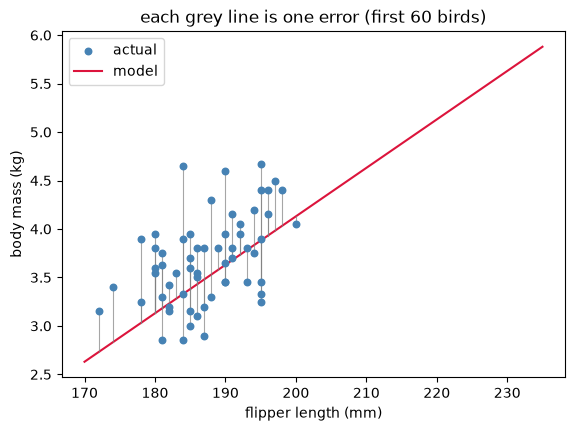

In [8]:
plt.figure(figsize=(6.5, 4.5))
sub = slice(0, 60)
plt.scatter(flipper[sub], mass[sub], s=22, color="steelblue", zorder=3, label="actual")
plt.plot(grid, w * grid + b, color="crimson", label="model")
for xi, yi in zip(flipper[sub], mass[sub]):
    plt.plot([xi, xi], [yi, w * xi + b], color="gray", lw=0.8, alpha=0.7)
plt.xlabel("flipper length (mm)")
plt.ylabel("body mass (kg)")
plt.title("each grey line is one error (first 60 birds)")
plt.legend()
plt.show()

---

## Measuring how wrong a model is

You can look at two lines and say which fits better. A computer cannot look. Every judgement it makes comes from comparing numbers, so the picture has to collapse into one number.

There are 333 errors if we are to consider the whole dataset, meaning we know how wrong the model is on each penguin. The obvious move is to add them up, but that fails: positive and negative errors cancel.

### Adding them fails

Take a model that ignores flipper length and predicts the average penguin every time: $w = 0$, so the feature contributes nothing, and $b = 4.21$, the average mass.

In [9]:
def average_error(w, b):
    return float((w * flipper + b - mass).mean())

print("flat line, always predicts 4.21 kg : average error %+.4f kg" % average_error(0.0, 4.21))
print("line that uses flipper length      : average error %+.4f kg" % average_error(0.05, -5.87))

flat line, always predicts 4.21 kg : average error +0.0029 kg
line that uses flipper length      : average error -0.0287 kg


The flat line scores as nearly perfect and the useful model scores worse.

The flat line is wrong about nearly every bird: too heavy for the small ones, too light for the large ones. Those errors have opposite signs and destroy each other in the sum. A measure that lets errors cancel is not measuring error.

### Squaring

Squaring removes the signs, so nothing cancels. It also makes big misses count for much more than small ones, since doubling an error quadruples its contribution.

The **loss** is one number rating how badly a model fits, smaller being better. This one is the mean squared error:

$$L(w, b) = \frac{1}{N}\sum_{i=1}^{N}\left(wx_i + b - y_i\right)^2$$

- $\sum$ means add up all of these. The $i = 1$ below and $N$ above say to do it once per example, here 333 times.
- $x_i$ and $y_i$ are the feature and true value for penguin $i$.
- $wx_i + b - y_i$ is that penguin's error.
- Squaring drops the sign.
- $\frac{1}{N}$ makes it an average, so the number does not grow just from collecting more penguins.

$L$ is a function of $w$ and $b$, not of $x$ and $y$. The data does not vary. The parameters do.

### Three penguins by hand

Scoring $w = 0.05$, $b = -5.87$:

| $x$ (mm) | $\hat{y} = 0.05x - 5.87$ | $y$ (kg) | error | error$^2$ |
|---|---|---|---|---|
| 190 | 3.630 | 3.650 | $-0.020$ | 0.0004 |
| 200 | 4.130 | 4.050 | $+0.080$ | 0.0064 |
| 210 | 4.630 | 4.800 | $-0.170$ | 0.0289 |

$$L = \frac{0.0004 + 0.0064 + 0.0289}{3} = \frac{0.0357}{3} = 0.0119$$

The third bird supplies 81% of the loss on its own, with an error only about twice the second bird's. The loss is dominated by the worst misses, so fixing those lowers it fastest.

In [10]:
def loss_for(w, b):
    """Mean squared error of y = wx + b over all 333 penguins."""
    errors = w * flipper + b - mass
    return float((errors ** 2).mean())

print("flat line, always predicts the average : loss %.4f" % loss_for(0.0, 4.21))
print("shallow line, w = 0.02, b = 0          : loss %.4f" % loss_for(0.02, 0.0))
print("the two-penguin line from earlier      : loss %.4f" % loss_for(0.05, -5.875))

flat line, always predicts the average : loss 0.6464
shallow line, w = 0.02, b = 0          : loss 0.3671
the two-penguin line from earlier      : loss 0.1549


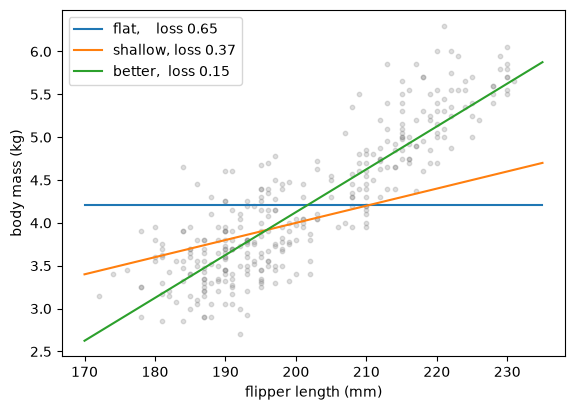

In [11]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(flipper, mass, s=10, alpha=0.25, color="gray")
plt.plot(grid, 0.0 * grid + 4.21, label="flat,    loss 0.65")
plt.plot(grid, 0.02 * grid + 0.0, label="shallow, loss 0.37")
plt.plot(grid, 0.05 * grid - 5.875, label="better,  loss 0.15")
plt.xlabel("flipper length (mm)")
plt.ylabel("body mass (kg)")
plt.legend()
plt.show()

The problem now has a sharp statement: find the $w$ and $b$ that make $L(w, b)$ smallest.

> **Aside.** Squared error is not the only loss and not always the right one. It is sensitive to outliers for exactly the reason above, so one mismeasured penguin can pull a fit around. There are losses built to resist that, and losses built for predicting categories rather than quantities. Choosing among them is a later week.

---

## Searching for good parameters

Three strategies. The first two work, then run out.

The bias stays fixed at $-5.87$ throughout, so there is one number to think about. That value is borrowed; finding it honestly is the same problem as finding $w$.

### Scanning

Try a lot of values, keep the best.

In [12]:
b_fixed = -5.87

print("     w        loss")
for w_try in torch.linspace(0.0, 0.10, 11):
    print("  %.3f    %8.4f" % (w_try, loss_for(float(w_try), b_fixed)))

     w        loss
  0.000    102.1935
  0.010     65.5523
  0.020     37.0278
  0.030     16.6200
  0.040      4.3290
  0.050      0.1546
  0.060      4.0970
  0.070     16.1561
  0.080     36.3319
  0.090     64.6244
  0.100    101.0336


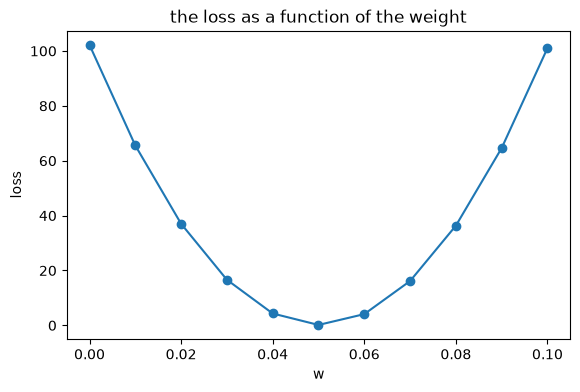

lowest on this grid: w = 0.050, loss = 0.1546


In [13]:
ws = torch.linspace(0.0, 0.10, 11)
losses = [loss_for(float(w_try), b_fixed) for w_try in ws]

plt.figure(figsize=(6.5, 4))
plt.plot(ws, losses, marker="o")
plt.xlabel("w")
plt.ylabel("loss")
plt.title("the loss as a function of the weight")
plt.show()

print("lowest on this grid: w = %.3f, loss = %.4f" % (ws[int(np.argmin(losses))], min(losses)))

A bowl: high at both ends, low in the middle.

The horizontal axis here is not a penguin measurement, it is a parameter. Each point on the curve is an entire model, scored against all 333 birds. Moving left or right swaps one model for another rather than moving along the data.

The loss has a shape, and the goal is the bottom of it.

### Why scanning dies

One parameter took 11 models. Two take 121, not 22, because every candidate $w$ has to be tried against every candidate $b$:

In [14]:
print("parameters   models to scan at 11 values each")
for n in [1, 2, 3, 6]:
    print("%9d   %15d" % (n, 11 ** n))

parameters   models to scan at 11 values each
        1                11
        2               121
        3              1331
        6           1771561


The count multiplies. Six parameters already needs over a million models, and the networks in this course have parameters in the millions. Scanning insists on seeing the whole bowl before choosing anything.

The bowl survives. A shape can be used locally, from where you stand.

### Nudging

Standing at one $w$, the only question is whether to move left or right. Ask it directly.

In [15]:
w_now = 0.02
step = 0.005

here = loss_for(w_now, b_fixed)
right = loss_for(w_now + step, b_fixed)
left = loss_for(w_now - step, b_fixed)

print("standing at w = %.3f" % w_now)
print("  loss here           : %8.4f" % here)
print("  loss if w increases : %8.4f" % right)
print("  loss if w decreases : %8.4f" % left)
print()
print("increasing w is downhill" if right < left else "decreasing w is downhill")

standing at w = 0.020
  loss here           :  37.0278
  loss if w increases :  25.8093
  loss if w decreases :  50.2755

increasing w is downhill


Increasing $w$ drops the loss from 37.03 to 25.81. Take the step, land at a new $w$, ask again.

This never needs the whole bowl, only the ground underfoot, so it does not collapse when a second parameter appears. But each of those three values cost a full pass over all 333 penguins, and finding the direction for one parameter took two extra passes:

In [16]:
print("parameters   extra passes over the data, per single step")
for n in [1, 2, 10, 1000]:
    print("%9d   %20d" % (n, 2 * n))

parameters   extra passes over the data, per single step
        1                      2
        2                      4
       10                     20
     1000                   2000


Half of that is guaranteed waste. One of the two directions was always uphill, and there is no way to know which without paying for both.

### What the nudge measured

The loss at $w + \text{step}$ compared against the loss at $w$ is a rate: how much the loss changed per unit of change in the weight. Same kind of object as the slope from the first section, except the thing varying is a parameter rather than a penguin.

In [17]:
rate = (right - here) / step

print("w changed by      %+.4f" % step)
print("loss changed by   %+.4f" % (right - here))
print("rate of change    %.2f loss per unit of w" % rate)
print()
print("negative rate, so increasing w decreases the loss" if rate < 0
      else "positive rate, so increasing w increases the loss")

w changed by      +0.0050
loss changed by   -11.2185
rate of change    -2243.70 loss per unit of w

negative rate, so increasing w decreases the loss


Both directions were never needed. One comparison gives the rate, and the sign of the rate gives the direction. The second measurement bought information the first already contained.

---

## The derivative, three ways

The **derivative** of the loss with respect to a parameter is the rate the loss changes as that parameter changes, at the parameter's current value. It is the slope of the loss curve at a single point, written $\frac{dL}{dw}$.

Its sign says which way to move. Its size says how sharply the loss responds, which is how much that parameter currently matters.

A derivative belongs to the problem, not to the procedure that found it. Below, the same one is computed three ways.

The penguins step aside for this. Nothing changes with real data, but 333 of anything will not fit in your head while following an argument.

One data point: $x = 2$, true value $y = 5$, starting at $w = 1$, $b = 0$.

In [35]:
x, y_true = 2.0, 5.0
w, b = 1.0, 0.0

prediction = w * x + b
error = prediction - y_true
loss = error ** 2

print("prediction : %.1f" % prediction)
print("error      : %.1f" % error)
print("loss       : %.1f" % loss)

prediction : 2.0
error      : -3.0
loss       : 9.0


Predicts 2, truth is 5, error $-3$, loss 9. What happens to that 9 if $w$ moves?

### By hand

The method rests on one question, asked repeatedly: if a quantity moves, how much does whatever depends on it move?

For multiplication by a constant the answer does not depend on where you are. If $f(x) = 3x$ and $x$ shifts, $f$ shifts three times as much:

In [19]:
def f(x):
    return 3 * x

print("f(x) = 3x, at x = 2")
for nudge in [1.0, 0.1, 0.01]:
    moved = f(2 + nudge) - f(2)
    print("  x moves %5.2f  ->  f moves %5.2f   (ratio %.2f)" % (nudge, moved, moved / nudge))

f(x) = 3x, at x = 2
  x moves  1.00  ->  f moves  3.00   (ratio 3.00)
  x moves  0.10  ->  f moves  0.30   (ratio 3.00)
  x moves  0.01  ->  f moves  0.03   (ratio 3.00)


Squaring does depend on where you are:

In [20]:
def g(x):
    return x ** 2

print("g(x) = x^2, at x = -3")
for nudge in [1.0, 0.1, 0.01, 0.001]:
    moved = g(-3 + nudge) - g(-3)
    print("  x moves %6.3f  ->  g moves %7.4f   (ratio %7.4f)" % (nudge, moved, moved / nudge))

g(x) = x^2, at x = -3
  x moves  1.000  ->  g moves -5.0000   (ratio -5.0000)
  x moves  0.100  ->  g moves -0.5900   (ratio -5.9000)
  x moves  0.010  ->  g moves -0.0599   (ratio -5.9900)
  x moves  0.001  ->  g moves -0.0060   (ratio -5.9990)


The ratio settles on $-6$, which is $2 \times (-3)$: twice the value you are standing at.

Now nudge $w$ upward and follow it through the calculation, one operation at a time:

| operation | effect on the movement | running factor |
|---|---|---|
| $w \times x$ | multiplies it by $x = 2$ | $2$ |
| $+\,b$ | adds a constant, movement untouched | $2$ |
| $-\,y$ | subtracts a constant, movement untouched | $2$ |
| $(\ \cdot\ )^2$ | multiplies it by twice the inside, $2 \times (-3) = -6$ | $2 \times (-6)$ |

In [21]:
through_multiply = x           # w * x  multiplies movement by x
through_add_bias = 1.0         # + b    constant, movement unchanged
through_subtract = 1.0         # - y    constant, movement unchanged
through_square = 2 * error     # (.)^2  multiplies movement by twice the inside

by_hand = through_multiply * through_add_bias * through_subtract * through_square
print("2 * 1 * 1 * (2 * %.0f) = %.1f" % (error, by_hand))

2 * 1 * 1 * (2 * -3) = -12.0


$-12$: the loss falls by 12 for every 1 that $w$ rises. Negative, so $w$ should increase.

The per-step factors were multiplied together, and the operations were visited in reverse, outermost first. Both have a general form and a name, and both are next week.

### By measurement

The nudge again, done carefully. Move $w$ by a small $h$, recompute, divide by $h$:

$$\frac{dL}{dw} \approx \frac{L(w + h) - L(w)}{h}$$

In [22]:
h = 0.001
loss_nudged = ((w + h) * x + b - y_true) ** 2

by_measurement = (loss_nudged - loss) / h
print("by measurement, h = %.3f : %.6f" % (h, by_measurement))

by measurement, h = 0.001 : -11.996000


$-11.996$, not $-12$. A derivative is the slope at a point; this is the average slope across a step of real width, and the curve bends along the way. Smaller steps do better, up to a limit shown at the end.

### By PyTorch

Creating a tensor with `requires_grad=True` marks it as worth tracking. Every value computed from it then records which operation produced it, and `.backward()` walks that record and fills in `.grad`.

In [23]:
w_t = torch.tensor(1.0, requires_grad=True)
b_t = torch.tensor(0.0)

loss_t = (w_t * x + b_t - y_true) ** 2
loss_t.backward()

print("by pytorch : %.4f" % w_t.grad)

by pytorch : -12.0000


The arithmetic is identical to the previous cell. The difference is one flag and one method call.

**Automatic differentiation**, or autograd, computes exact derivatives by recording operations during a calculation and traversing that record backwards. Not approximation, and not manipulating formulas on paper.

In [24]:
print("by hand        : %8.4f" % by_hand)
print("by measurement : %8.4f" % by_measurement)
print("by pytorch     : %8.4f" % w_t.grad)

by hand        : -12.0000
by measurement : -11.9960
by pytorch     : -12.0000


Two agree exactly, the third is close and known to be approximate.

| method | exact? | cost | where it breaks |
|---|---|---|---|
| by hand | yes | your time | error-prone past a few operations, hopeless past a few parameters |
| by measurement | no | one pass per parameter | slow, approximate, needs a step size chosen well |
| autograd | yes | one pass, all parameters | nothing at this scale |

### On the full problem

Both parameters, all 333 penguins, one call:

In [25]:
w_t = torch.tensor(0.02, requires_grad=True, dtype=torch.float64)
b_t = torch.tensor(-5.87, requires_grad=True, dtype=torch.float64)

loss_t = ((w_t * flipper + b_t - mass) ** 2).mean()
loss_t.backward()

print("loss        : %10.4f" % loss_t.item())
print("d loss / d w: %10.2f" % w_t.grad.item())
print("d loss / d b: %10.2f" % b_t.grad.item())

loss        :    37.0278
d loss / d w:   -2446.61
d loss / d b:     -12.12


Both negative, so both parameters should increase. Nudging would have cost four extra passes to learn the same two facts.

In [26]:
fine = 1e-6
fine_rate = (loss_for(0.02 + fine, b_fixed) - loss_for(0.02, b_fixed)) / fine

print("by nudging, step = 0.005 : %10.2f" % rate)
print("by nudging, step = 1e-6  : %10.2f" % fine_rate)
print("by autograd              : %10.2f" % w_t.grad.item())

by nudging, step = 0.005 :   -2243.70
by nudging, step = 1e-6  :   -2446.57
by autograd              :   -2446.61


The coarse nudge was off by about 200. Across a step of 0.005 the bowl has already started to bend, so what got measured was an average slope over that interval rather than the slope at the point. A smaller step nearly closes it. Autograd never picked a step at all.

---

## Summary

| term | what it is | in $y = 0.05x - 5.87$ |
|---|---|---|
| feature | an input measured from the world | $x$, flipper length |
| weight | multiplies a feature; a rate, with units | $0.05$ kg/mm |
| bias | added to the output, multiplies nothing | $-5.87$ kg |
| parameter | any number the model chooses | both of the above |
| prediction | what the model returns, $\hat{y}$ | $0.05x - 5.87$ |
| error | $\hat{y} - y$, signed | one per penguin |
| loss | one number rating a whole model | $0.15$ |
| derivative | rate the loss changes as one parameter changes | $-2446.61$ at $w = 0.02$ |
| autograd | exact derivatives from recorded operations | `.backward()` |

Parameters are unlike data. The data is measured and fixed; the parameters are chosen and adjustable, and fitting only touches the second kind. A loss compresses a whole model into one comparable number, and squaring the errors is what stops mistakes from cancelling. The derivative of the loss with respect to a parameter says which way that parameter should move and how strongly the loss reacts. Autograd supplies it exactly, for one parameter or millions, for one function call.

In 1962 Arthur Samuel, who built one of the first programs that improved with experience, put it this way:

> Suppose we arrange for some automatic means of testing the effectiveness of any current weight assignment in terms of actual performance and provide a mechanism for altering the weight assignment so as to maximize the performance.

Weights, a test of any particular choice of them, and a mechanism for improving that choice. This notebook covered the first two and most of the third. Knowing which way to walk is not yet walking there, which is Thursday.

The chaining done by hand has a general form and a name, and there is a specific reason autograd computes a million derivatives about as cheaply as one. Both are next week.

---

## Further exploration

Optional. Each block stands alone.

### The bias has a bowl too

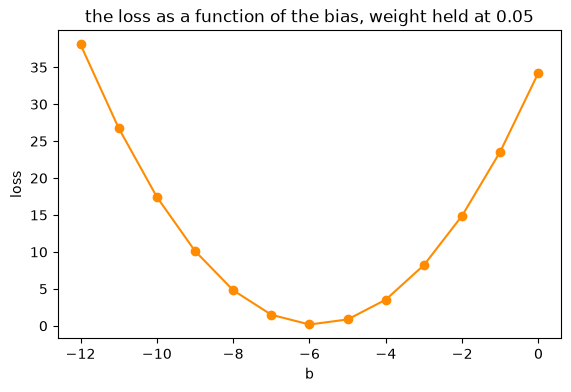

lowest on this grid: b = -6.0


In [27]:
bs = torch.linspace(-12.0, 0.0, 13)
b_losses = [loss_for(0.05, float(b_try)) for b_try in bs]

plt.figure(figsize=(6.5, 4))
plt.plot(bs, b_losses, marker="o", color="darkorange")
plt.xlabel("b")
plt.ylabel("loss")
plt.title("the loss as a function of the bias, weight held at 0.05")
plt.show()

print("lowest on this grid: b = %.1f" % bs[int(np.argmin(b_losses))])

With both parameters free the bowl becomes a surface in three dimensions, and with a thousand parameters it stops being drawable. The mathematics is unchanged; only the picture gives out.

### How small can the measuring step get

A computer stores about sixteen significant digits, and subtracting two nearly equal numbers throws most of them away.

In [28]:
print(" step size     measured        error vs -12")
for power in range(1, 15):
    hh = 10.0 ** (-power)
    measured = (((w + hh) * x + b - y_true) ** 2 - loss) / hh
    print("   1e-%-2d      %12.6f      %+.6f" % (power, measured, measured - by_hand))

 step size     measured        error vs -12
   1e-1         -11.600000      +0.400000
   1e-2         -11.960000      +0.040000
   1e-3         -11.996000      +0.004000
   1e-4         -11.999600      +0.000400
   1e-5         -11.999960      +0.000040
   1e-6         -11.999996      +0.000004
   1e-7         -12.000000      +0.000000
   1e-8         -12.000000      +0.000000
   1e-9         -12.000001      -0.000001
   1e-10        -12.000001      -0.000001
   1e-11        -12.000001      -0.000001
   1e-12        -12.001067      -0.001067
   1e-13        -11.990409      +0.009591
   1e-14        -12.079227      -0.079227


Best near $h = 10^{-8}$, then precision loss takes over. Choosing $h$ is a real problem with no clean solution, which is the second argument for autograd after speed.

### What requires_grad turns on

In [29]:
a = torch.tensor(3.0, requires_grad=True)
step1 = a * 2
step2 = step1 + 1
step3 = step2 ** 2

print("step1 was produced by:", step1.grad_fn)
print("step2 was produced by:", step2.grad_fn)
print("step3 was produced by:", step3.grad_fn)

step1 was produced by: <MulBackward0 object at 0x11eefcdc0>
step2 was produced by: <AddBackward0 object at 0x11f1c80a0>
step3 was produced by: <PowBackward0 object at 0x11f1c8310>


One entry per operation, in the order they happened. That chain is the four-row table from earlier, built automatically, and it is what `.backward()` walks back along. Before it is called there is nothing to read:

In [30]:
a = torch.tensor(3.0, requires_grad=True)
out = (a * 2 + 1) ** 2

print("a.grad before backward():", a.grad)
out.backward()
print("a.grad after backward() :", a.grad)

a.grad before backward(): None
a.grad after backward() : tensor(28.)
